## Spaceship Titanic Survival Prediction:

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
# loading dataset
df = pd.read_csv("train.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

First 5 rows:
  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4    

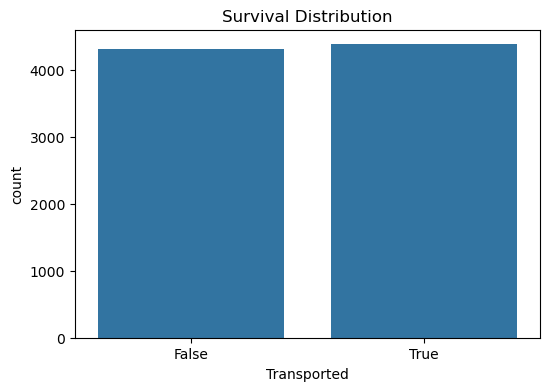

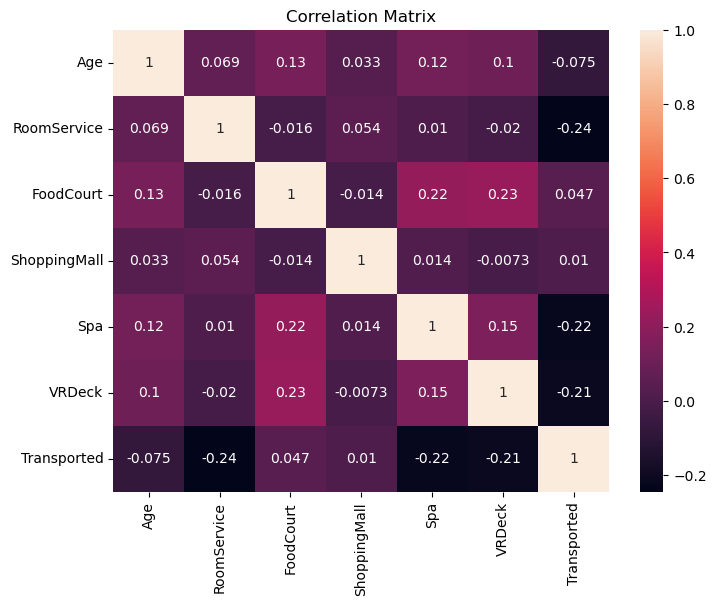

C:\Users\DELL\AppData\Local\Temp\ipykernel_15372\3634197174.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [10]:
# Basic EDA
plt.figure(figsize=(6,4))
sns.countplot(x="Transported", data=df)
plt.title("Survival Distribution")
plt.show()
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

# Handling Missing Values
# Fill numeric columns with median
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])


# 5. Encoding Categorical Columns
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [11]:
# Splitting Data
X = df.drop("Transported", axis=1)
y = df["Transported"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("\nTraining size:", X_train.shape)
print("Testing size:", X_test.shape)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Training size: (6954, 13)
Testing size: (1739, 13)


In [12]:
# Training Random Forest Model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Model Evaluation
print("\nModel Accuracy:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n")
print(classification_report(y_test, predictions))
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, predictions))


Model Accuracy: 0.7935595169637722

Classification Report:

              precision    recall  f1-score   support

       False       0.81      0.77      0.79       861
        True       0.78      0.82      0.80       878

    accuracy                           0.79      1739
   macro avg       0.79      0.79      0.79      1739
weighted avg       0.79      0.79      0.79      1739

Confusion Matrix:

[[659 202]
 [157 721]]


In [13]:
# Saving Predictions to CSV

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

results.to_csv("model_predictions.csv", index=False)
print("\nPredictions saved successfully as 'model_predictions.csv'")


Predictions saved successfully as 'model_predictions.csv'
